In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
a,b,n,k=sp.symbols('a,b,n,k',positive=True, integer=True)
seq=1/(b-a+1)# 离散的情况下会+1点
val=sp.Sum(n*seq,(n,a,b))
val

Sum(n/(-a + b + 1), (n, a, b))

In [31]:
sp.cancel(val.doit())

a/2 + b/2

In [26]:
x=sp.symbols('x',real=True)
sp.cancel(sp.Integral(x * seq,(x,a,b)).doit())

a/2 + b/2

In [21]:
sp.cancel(sp.Sum((1/n)*k,(k,1,n)).doit())

n/2 + 1/2

In [ ]:
#
x,y=sp.symbols('x,y',positive=True)
fx=2*x+2-y
fxi=sp.solve(fx,x)[0]

sp.apart(2-fxi)*fxi.diff()


3/2 - y/4

In [51]:
# 指数分布
x,y=sp.symbols('x,y',positive=True)
f=(1/y)*sp.E**-(x/y)
f

exp(-x/y)/y

In [52]:
sp.Integral(f,(x,0,sp.oo)).doit()

1

In [53]:
sp.Integral(x*f,(x,0,sp.oo)).doit()

y

In [2]:
x=sp.symbols('x')
fx=sp.E**-x
fx

exp(-x)

In [4]:
sp.Integral(fx,(x,0,sp.oo)).doit()

1

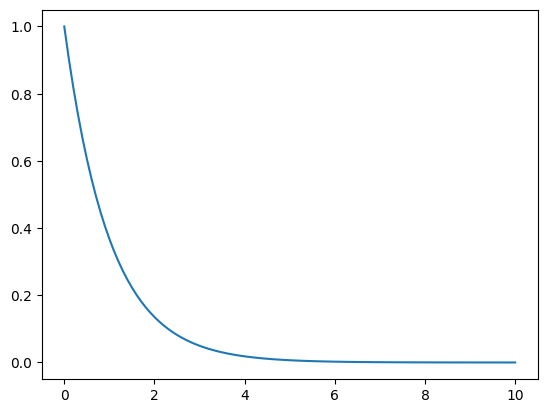

In [5]:
idx=np.linspace(0,10,101)
plt.plot(idx,np.e**-idx)

In [ ]:
# 时间窗口和频次互为倒数
sp.Integral(sp.Rational(1,30)*sp.E**(-x/30),(x,45,sp.oo)).doit()

exp(-3/2)

In [ ]:
# 1小时内进2个球 注意单位
sp.Integral(2*sp.E**(-x*2),(x,sp.Rational(3,4),sp.oo)).doit()

exp(-3/2)

In [18]:

# 定义符号：t是时间，x是积分替换变量，lam是频率（告诉系统它们都是正数，方便化简）
t, x, lam = sp.symbols('t x lam', positive=True)

# 初始状态：n=1 的情况（即标准的指数分布）
f_base = lam * sp.exp(-lam * t)

# 设定你想推导的阶数 n（比如等待 4 辆车，你可以随便改这个数字）
n = 4

# f_current 用来保存每一轮接龙后的结果
f_current = f_base

# 从第 2 辆车开始，进行连续的卷积接龙
for i in range(2, n + 1):
    # 构造卷积积分里面的被积函数：f_current(x) * f_base(t-x)
    integrand = f_current.subs(t, x) * f_base.subs(t, t - x)
    
    # 执行积分 (从 0 到 t)
    f_current = sp.Integral(integrand, (x, 0, t)).doit()

print(f"--- 等待 {n} 辆车的爱尔兰分布 PDF ---")
# 打印化简后的漂亮公式
sp.pprint(f_current.simplify())

--- 等待 4 辆车的爱尔兰分布 PDF ---
   4  3  -lam⋅t
lam ⋅t ⋅ℯ      
───────────────
       6       
